## Introduction
Earthquakes are naturally occurring phenomena which can cause important effects for societies and their infrastructures. The study of patterns in past earthquakes will help in determining locations of major earthquake occurrences and the difference in features of earthquakes with respect to time and place. This project aims to analyze a world database of significant seismic activities since 1900.

---

## Problem Statement
The analysis of 109,282 earthquake records since 1900 shows that significant earthquake activity varies across locations and over time. Nearly half of the recorded earthquakes (49.15%) occurred from 2000 onward, while the strongest earthquake in the dataset reached a magnitude of 9.5. Understanding these differences in earthquake frequency, magnitude, location, and other characteristics can help governments and urban planners better understand historical seismic activity and identify areas that may require greater attention for earthquake preparedness and infrastructure planning.


---

## Objectives:
1. Identify the locations with the highest frequency of significant earthquakes since 1900.
2. Identify the locations that experienced the strongest earthquakes based on maximum and average magnitude.
3. Analyze how earthquake frequency and average magnitude have changed over time since 1900.
4. Examine the relationship between earthquake depth and magnitude.
5. Analyze how earthquake frequency varies by month and time of day.
6. Examine the relationship between earthquake magnitude and the number of reporting stations (nst).
7. Identify the different seismic event types in the dataset and compare their average magnitude and depth.
---

## Exploratory Data Analysis (EDA):

### Data Info:


In [1]:
import pandas as pd

In [2]:
earthquake_df= pd.read_csv('Significant_Earthquakes.csv', index_col=0)

In [3]:
earthquake_df.shape

(116093, 22)

In [4]:
earthquake_df.head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,1900-10-09T12:25:00.000Z,57.09,-153.48,NaN,7.86,mw,NaN,NaN,NaN,NaN,...,2022-05-09T14:44:17.838Z,"16 km SW of Old Harbor, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,pt
1,1901-03-03T07:45:00.000Z,36.00,-120.50,NaN,6.40,ms,NaN,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,"12 km NNW of Parkfield, California",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,ell
2,1901-07-26T22:20:00.000Z,40.80,-115.70,NaN,5.00,fa,NaN,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,"6 km SE of Elko, Nevada",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,sjg
3,1901-12-30T22:34:00.000Z,52.00,-160.00,NaN,7.00,ms,NaN,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,south of Alaska,earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,abe
4,1902-01-01T05:20:30.000Z,52.38,-167.45,NaN,7.00,ms,NaN,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,"113 km ESE of Nikolski, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,abe


In [5]:
earthquake_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 116093 entries, 0 to 116092
Data columns (total 22 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   time             116093 non-null  str    
 1   latitude         116093 non-null  float64
 2   longitude        116093 non-null  float64
 3   depth            115808 non-null  float64
 4   mag              116093 non-null  float64
 5   magType          116093 non-null  str    
 6   nst              45448 non-null   float64
 7   gap              55729 non-null   float64
 8   dmin             35785 non-null   float64
 9   rms              87346 non-null   float64
 10  net              116093 non-null  str    
 11  id               116093 non-null  str    
 12  updated          116093 non-null  str    
 13  place            115202 non-null  str    
 14  type             116093 non-null  str    
 15  horizontalError  34408 non-null   float64
 16  depthError       66378 non-null   float64
 17  ma

In [6]:
earthquake_df.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,116093.000000,116093.000000,115808.000000,116093.000000,45448.000000,55729.000000,35785.000000,87346.000000,34408.000000,66378.000000,49013.000000,56057.000000
mean,3.712151,41.612922,60.880170,5.435555,134.016040,66.594226,4.224854,0.940920,7.973105,6.937956,0.138815,66.561357
std,30.519119,121.962322,107.000352,0.476252,112.100173,39.293152,5.175846,0.364756,3.733222,9.763007,0.139495,103.503024
min,-77.080000,-179.997000,-4.000000,5.000000,0.000000,6.500000,0.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000
25%,-17.855000,-71.951000,10.000000,5.100000,61.000000,38.000000,1.336000,0.800000,6.300000,1.878000,0.054000,14.000000
50%,-0.462000,101.223000,33.000000,5.300000,98.000000,58.000000,2.542000,0.940000,7.900000,4.500000,0.078000,31.000000
75%,29.954900,143.190000,51.200000,5.600000,167.000000,86.000000,4.959000,1.100000,9.500000,7.600000,0.200000,70.000000
max,87.386000,180.000000,700.000000,9.500000,929.000000,360.000000,50.901000,69.320000,99.000000,1091.900000,1.840000,1144.000000


### Data Handling:

In [7]:
# most nulls at horizontalError<--->70.361693

earthquake_df.isnull().mean()*100

time                0.000000
latitude            0.000000
longitude           0.000000
depth               0.245493
mag                 0.000000
magType             0.000000
nst                60.852075
gap                51.996244
dmin               69.175575
rms                24.762044
net                 0.000000
id                  0.000000
updated             0.000000
place               0.767488
type                0.000000
horizontalError    70.361693
depthError         42.823426
magError           57.781262
magNst             51.713712
status              0.000000
locationSource      0.000000
magSource           0.000000
dtype: float64

In [8]:
earthquake_df.duplicated().sum()

np.int64(6317)

In [9]:
earthquake_df[earthquake_df.duplicated()].head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
96066,2023-03-29T18:26:49.386Z,-15.2968,-173.0504,10.000,5.4,mww,54.0,43.0,2.622,0.93,...,2023-03-30T18:30:40.369Z,"108 km NE of Hihifo, Tonga",earthquake,7.70,1.866,0.098,10.0,reviewed,us,us
96067,2023-03-19T15:06:27.280Z,59.6095,-151.9070,65.400,5.4,mww,NaN,NaN,NaN,0.49,...,2023-03-30T15:16:30.474Z,"19 km SSW of Anchor Point, Alaska",earthquake,NaN,0.300,NaN,NaN,reviewed,ak,ak
96068,2023-03-18T17:12:52.583Z,-2.8367,-79.8436,65.842,6.8,mww,152.0,28.0,0.709,1.27,...,2023-03-30T15:57:31.960Z,"8 km NNW of Baláo, Ecuador",earthquake,6.64,3.333,0.038,68.0,reviewed,us,us
96071,2023-03-08T13:43:23.060Z,11.4068,141.4394,10.000,5.4,mww,87.0,47.0,3.990,0.58,...,2023-03-30T13:53:27.127Z,"207 km NNE of Fais, Micronesia",earthquake,7.46,1.594,0.061,26.0,reviewed,us,us
96072,2023-03-03T09:41:20.779Z,-5.9180,154.5022,80.600,5.0,mb,96.0,94.0,2.892,0.39,...,2023-03-30T12:59:39.040Z,"117 km WNW of Panguna, Papua New Guinea",earthquake,11.50,7.000,0.051,125.0,reviewed,us,us


In [10]:
earthquake_df[earthquake_df['time'] == '2023-03-29 18:26:49.386000+00:00'].T

""
time
latitude
longitude
depth
mag
magType
nst
gap
dmin
rms


In [12]:
earthquake_df.duplicated().sum()

np.int64(0)

In [11]:
earthquake_df.drop_duplicates(inplace=True)

In [13]:
earthquake_df['time']= pd.to_datetime(earthquake_df['time'])

In [14]:
earthquake_df.time

0               1900-10-09 12:25:00+00:00
1               1901-03-03 07:45:00+00:00
2               1901-07-26 22:20:00+00:00
3               1901-12-30 22:34:00+00:00
4               1902-01-01 05:20:30+00:00
                       ...               
116088   2026-08-29 05:40:06.270000+00:00
116089   2026-08-28 20:19:38.561000+00:00
116090   2026-08-28 09:12:16.798000+00:00
116091   2026-08-28 05:13:35.089000+00:00
116092   2026-08-28 04:59:06.858000+00:00
Name: time, Length: 109776, dtype: datetime64[us, UTC]

In [15]:
earthquake_df.head(5).T

,0,1,2,3,4
time,1900-10-09 12:25:00+00:00,1901-03-03 07:45:00+00:00,1901-07-26 22:20:00+00:00,1901-12-30 22:34:00+00:00,1902-01-01 05:20:30+00:00
latitude,57.09,36.0,40.8,52.0,52.38
longitude,-153.48,-120.5,-115.7,-160.0,-167.45
depth,NaN,NaN,NaN,NaN,NaN
mag,7.86,6.4,5.0,7.0,7.0
magType,mw,ms,fa,ms,ms
nst,NaN,NaN,NaN,NaN,NaN
gap,NaN,NaN,NaN,NaN,NaN
dmin,NaN,NaN,NaN,NaN,NaN
rms,NaN,NaN,NaN,NaN,NaN


### Analysis:

### Objective 1
Which locations have experienced the highest frequency of significant earthquakes since 1900?

In [18]:
earthquake_df.head(3).T

,0,1,2
time,1900-10-09 12:25:00+00:00,1901-03-03 07:45:00+00:00,1901-07-26 22:20:00+00:00
latitude,57.09,36.0,40.8
longitude,-153.48,-120.5,-115.7
depth,NaN,NaN,NaN
mag,7.86,6.4,5.0
magType,mw,ms,fa
nst,NaN,NaN,NaN
gap,NaN,NaN,NaN
dmin,NaN,NaN,NaN
rms,NaN,NaN,NaN


In [19]:
earthquake_df[earthquake_df.mag == earthquake_df.mag.max()].T

,9869
time,1960-05-22 19:11:20+00:00
latitude,-38.143
longitude,-73.407
depth,25.0
mag,9.5
magType,mw
nst,NaN
gap,NaN
dmin,NaN
rms,NaN


In [20]:
earthquake_df.place.value_counts()

place
South Sandwich Islands region     2509
Kermadec Islands region           1620
south of the Fiji Islands         1477
Kermadec Islands, New Zealand     1092
Fiji region                        940
                                  ... 
112 km WNW of Pangai, Tonga          1
96 km SE of Maba, Indonesia          1
40 km NNE of Ruteng, Indonesia       1
67 km W of Labuha, Indonesia         1
22 km NW of Fuji, China              1
Name: count, Length: 64412, dtype: int64

In [21]:
forearth=earthquake_df[earthquake_df.type == 'earthquake']
p1=forearth.place.value_counts().head(10)
p1

place
South Sandwich Islands region    2509
Kermadec Islands region          1620
south of the Fiji Islands        1477
Kermadec Islands, New Zealand    1092
Fiji region                       940
south of the Kermadec Islands     909
northern Mid-Atlantic Ridge       779
southern Mid-Atlantic Ridge       744
Pacific-Antarctic Ridge           693
Kuril Islands                     674
Name: count, dtype: int64

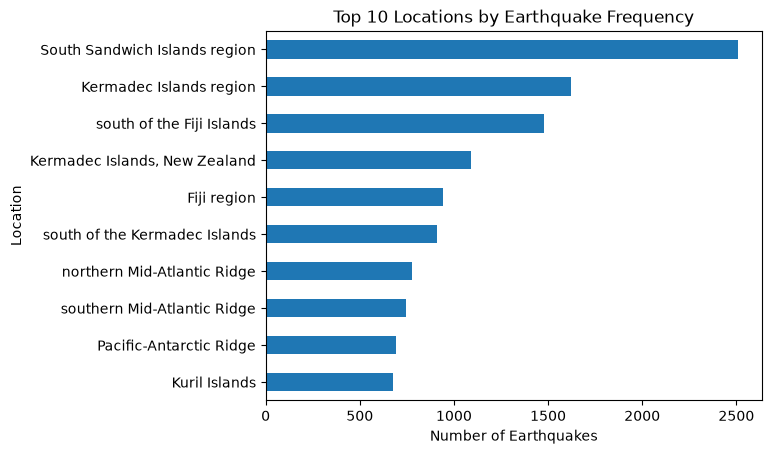

In [22]:
p1.sort_values().plot(
    kind='barh',
    title='Top 10 Locations by Earthquake Frequency',
    xlabel='Number of Earthquakes',
    ylabel='Location',
    
);

**Finding:** The South Sandwich Islands region had the highest number of recorded earthquakes with 2,509 events, followed by the Kermadec Islands region with 1,620 and south of the Fiji Islands with 1,477. This shows that earthquake activity in the dataset is more concentrated in certain locations.

### Objective 2
Which locations have experienced the strongest earthquakes, based on average and maximum magnitude?

In [23]:
# Creates the summary table for every location:
#    → maximum magnitude, average magnitude, number of earthquakes.

maxmean=forearth.groupby('place')['mag'].agg(['max','mean','count'])
maxmean

,max,mean,count
place,,,
"0 km E of Avigliana, Italy",5.50,5.500000,1
"0 km E of Becerreá, Spain",5.10,5.100000,1
"0 km E of Cervantes, Philippines",5.10,5.100000,1
"0 km E of Gavaloú, Greece",5.10,5.100000,1
"0 km E of Golfito, Costa Rica",5.10,5.100000,1
...,...,...,...
western Indian-Antarctic Ridge,6.60,5.434513,277
western Iran,5.50,5.290000,4
"western Nei Mongol, China",6.35,6.350000,1


In [24]:
#Finds the strongest individual earthquake per location and keeps extra information from the original row:
#    → location, magnitude, year it happened.


forearth['year'] = forearth['time'].dt.year
max_indices = forearth.groupby('place')['mag'].idxmax()

strongest_by_place = forearth.loc[
    max_indices,
    ['place', 'mag', 'year']
].sort_values(by='mag', ascending=False).head(10)

strongest_by_place

,place,mag,year
9869,1960 Great Chilean Earthquake (Valdivia Earthq...,9.5,1960
10932,"1964 Prince William Sound Earthquake, Alaska",9.2,1964
75957,"2011 Great Tohoku Earthquake, Japan",9.1,2011
62882,2004 Sumatra - Andaman Islands Earthquake,9.1,2004
7785,"89 km ESE of Petropavlovsk-Kamchatsky, Russia",9.0,1952
108133,"2025 Kamchatka Peninsula, Russia Earthquake",8.8,2025
73025,"36 km WNW of Quirihue, Chile",8.8,2010
11422,"Rat Islands, Aleutian Islands, Alaska",8.7,1965
63500,"78 km WSW of Singkil, Indonesia",8.6,2005
7133,1950 Assam-Tibet Earthquake,8.6,1950


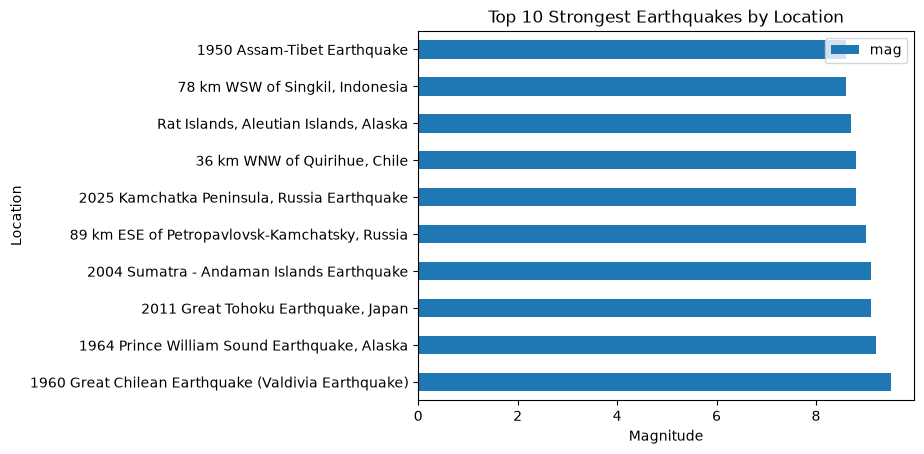

In [25]:
strongest_by_place.plot(
    x='place',
    y='mag',
    kind='barh',
    title='Top 10 Strongest Earthquakes by Location',
    xlabel='Magnitude',
    ylabel='Location'
);

In [26]:
#Finds locations with the highest average magnitude, but only locations
#    with at least 10 earthquakes so the average is more meaningful.

avgloc=maxmean[maxmean['count'] >= 10].sort_values(
    by='mean',
    ascending=False
).head(10)
avgloc

,max,mean,count
place,,,
Nepal,8.00,5.911818,11
Azores-Cape St. Vincent Ridge,7.90,5.903529,17
Taiwan,7.81,5.897500,16
Sea of Okhotsk,8.30,5.880000,42
"Haida Gwaii Region, Canada",6.49,5.872727,11
off the west coast of the South Island of New Zealand,7.60,5.863889,18
"Hindu Kush region, Afghanistan",7.50,5.847692,13
"off the east coast of the Kamchatka Peninsula, Russia",7.84,5.799130,23
Gulf of Alaska,7.80,5.767000,10


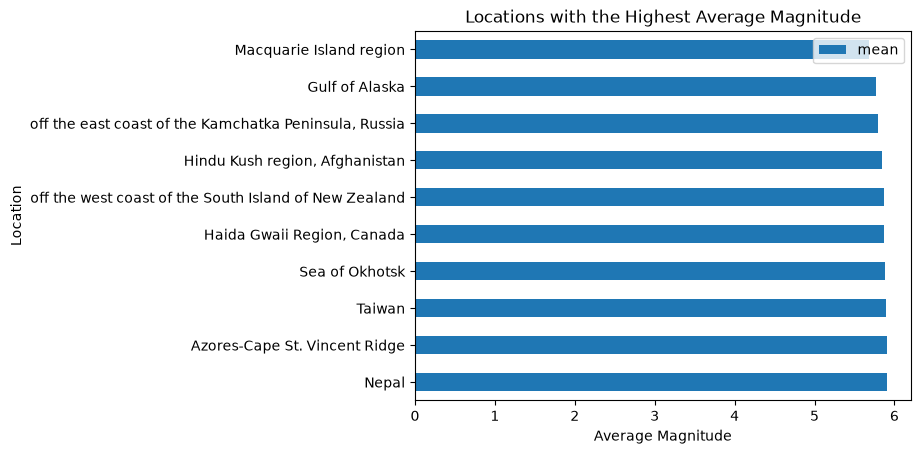

In [27]:
avgloc.plot(
    y='mean',
    kind='barh',
    title='Locations with the Highest Average Magnitude',
    xlabel='Average Magnitude',
    ylabel='Location'
);

**Finding:** The strongest earthquake in the dataset was the 1960 Great Chilean (Valdivia) Earthquake, with a magnitude of 9.5, followed by the 1964 Prince William Sound Earthquake in Alaska at 9.2. When comparing average magnitude among locations with at least 10 recorded earthquakes, Nepal had the highest average magnitude at approximately 5.91, followed closely by the Azores-Cape St. Vincent Ridge at 5.90 and Taiwan at 5.90.

### Objective 3
How have earthquake frequency and magnitude changed over time since 1900?

In [28]:
fre=forearth.year.value_counts().sort_index()
fre

year
1900       1
1901       3
1902       4
1903       6
1904      11
        ... 
2022    1658
2023    3382
2024    3160
2025    4401
2026    3189
Name: count, Length: 127, dtype: int64

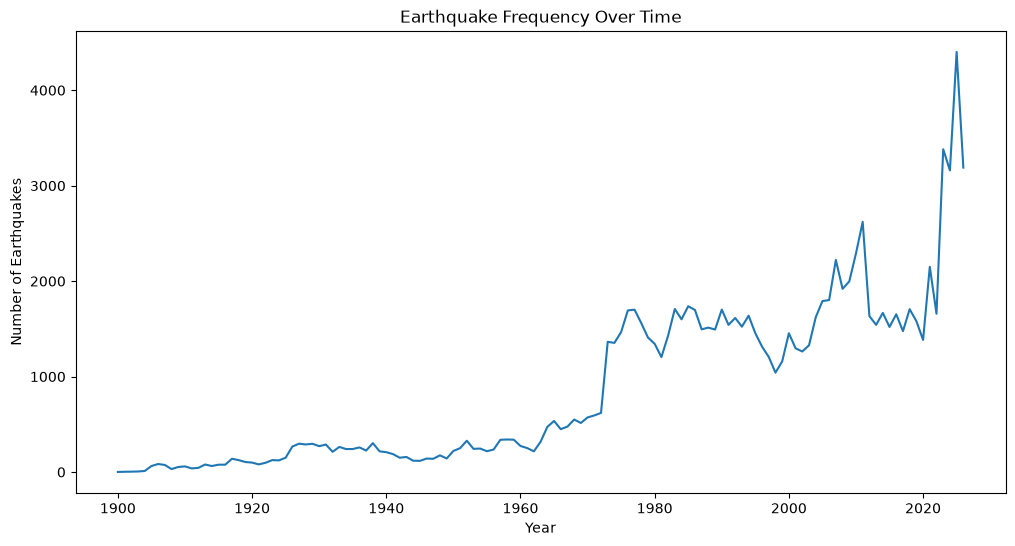

In [29]:
fre.plot(
    kind='line',
    title='Earthquake Frequency Over Time',
    xlabel='Year',
    ylabel='Number of Earthquakes',
    figsize=(12, 6)
);

In [30]:
magn=forearth.groupby('year')['mag'].mean()
magn

year
1900    7.860000
1901    6.133333
1902    6.025000
1903    6.233333
1904    6.759091
          ...   
2022    5.324837
2023    5.380565
2024    5.334142
2025    5.350530
2026    5.341577
Name: mag, Length: 127, dtype: float64

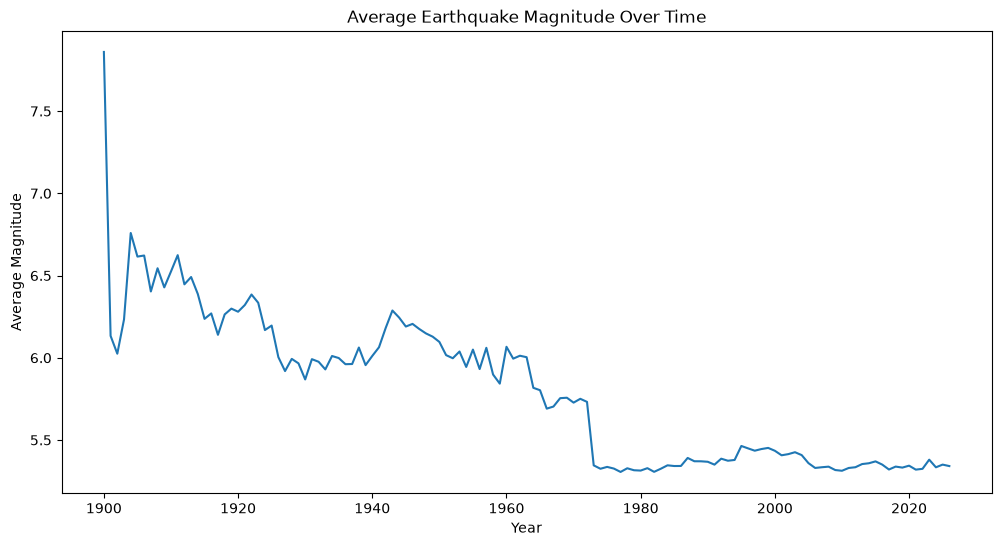

In [31]:
magn.plot(
    kind='line',
    title='Average Earthquake Magnitude Over Time',
    xlabel='Year',
    ylabel='Average Magnitude',
    figsize=(12, 6)
);

**Finding:** The number of recorded earthquakes generally increased over time, with 2025 having the highest recorded frequency at 4,401 earthquakes. In contrast, the average recorded magnitude generally decreased over time and has remained relatively stable at around 5.3–5.4 in recent decades.

### Objective 4
Is there a relationship between earthquake depth and magnitude?

In [32]:
#“The correlation was approximately −0.01,
#indicating almost no linear relationship between earthquake depth and magnitude.”
relation=forearth[['depth','mag']]
relation.corr()

,depth,mag
depth,1.000000,-0.012542
mag,-0.012542,1.000000


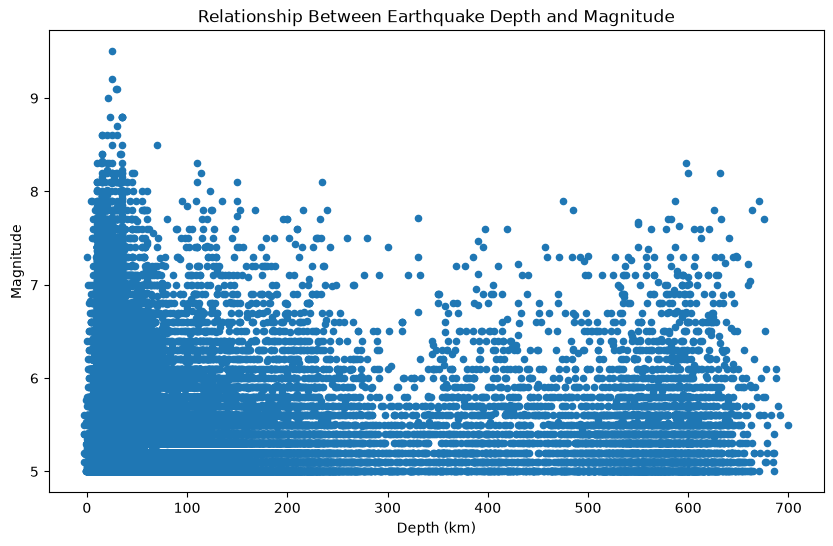

In [33]:
relation.plot(
    kind='scatter',
    x='depth',
    y='mag',
    title='Relationship Between Earthquake Depth and Magnitude',
    xlabel='Depth (km)',
    ylabel='Magnitude',
    figsize=(10, 6)
);

**Finding:** The correlation between earthquake depth and magnitude is approximately -0.01, indicating almost no linear relationship between the two variables. This suggests that deeper earthquakes are not necessarily stronger or weaker based on this dataset.

### Objective 5
How does earthquake frequency vary by month and time of day?

In [34]:
forearth['month'] = forearth['time'].dt.month
forearth['hour'] = forearth['time'].dt.hour

In [35]:
forearth[['month','hour']]

,month,hour
0,10,12
1,3,7
2,7,22
3,12,22
4,1,5
...,...,...
116088,8,5
116089,8,20
116090,8,9
116091,8,5


In [36]:
forearth['time_of_day'] = pd.cut(
    forearth['hour'],
    bins=[0, 6, 12, 18, 24],
    labels=[
        'Night (0–6)',
        'Morning (6–12)',
        'Afternoon (12–18)',
        'Evening (18–24)'
    ],
    include_lowest=True
)

In [37]:
forearth[['month','time_of_day']]

,month,time_of_day
0,10,Morning (6–12)
1,3,Morning (6–12)
2,7,Evening (18–24)
3,12,Evening (18–24)
4,1,Night (0–6)
...,...,...
116088,8,Night (0–6)
116089,8,Evening (18–24)
116090,8,Morning (6–12)
116091,8,Night (0–6)


In [38]:
forearth['month'].value_counts().sort_index()

month
1     9100
2     8333
3     9833
4     9009
5     8992
6     8735
7     9600
8     9477
9     8894
10    8956
11    8842
12    9511
Name: count, dtype: int64

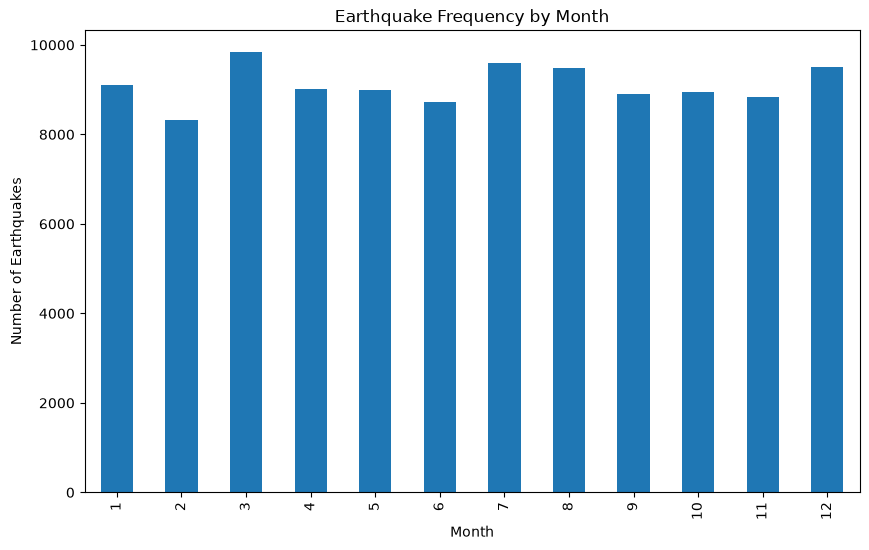

In [39]:
# Earthquake frequency by month
forearth['month'].value_counts().sort_index().plot(
    kind='bar',
    title='Earthquake Frequency by Month',
    xlabel='Month',
    ylabel='Number of Earthquakes',
    figsize=(10, 6)
);

In [40]:
forearth['time_of_day'].value_counts()

time_of_day
Night (0–6)          31766
Afternoon (12–18)    27575
Morning (6–12)       26917
Evening (18–24)      23024
Name: count, dtype: int64

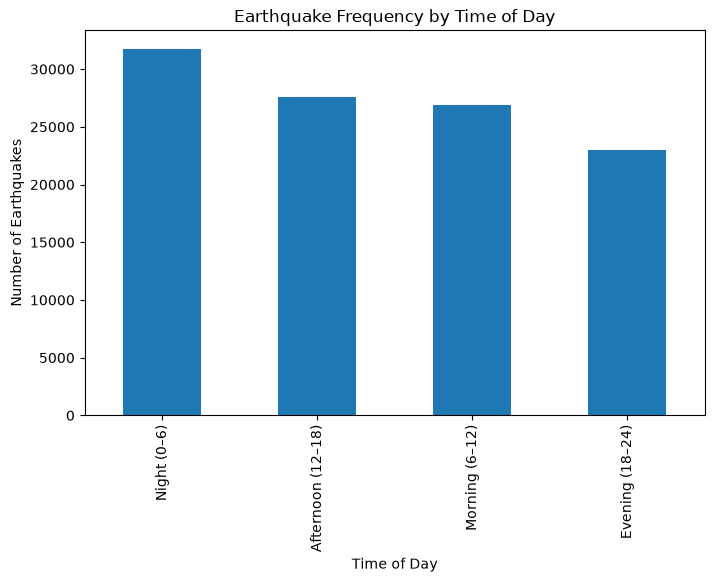

In [41]:
# Earthquake frequency by time of day
forearth['time_of_day'].value_counts().plot(
    kind='bar',
    title='Earthquake Frequency by Time of Day',
    xlabel='Time of Day',
    ylabel='Number of Earthquakes',
    figsize=(8, 5)
);

**Finding:** Based on UTC time, the 0–6 hour period contained the highest number of recorded earthquakes (31,766), while 18–24 had the lowest (23,024). Since the dataset uses UTC rather than each location's local time, these results should not be interpreted as earthquakes occurring more frequently during local nighttime.

### Objective 6
Is there a relationship between the number of reporting stations (nst) and earthquake magnitude?

In [42]:
forearth.columns

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource', 'year', 'month', 'hour', 'time_of_day'],
      dtype='str')

In [45]:
forearth[['nst','mag']].max()

nst    929.0
mag      9.5
dtype: float64

In [47]:
station_relation = forearth[['nst', 'mag']].dropna()

In [48]:
#“A moderate positive correlation (0.46) was found 
#between earthquake magnitude and the number of reporting stations.”
station_relation.corr()

,nst,mag
nst,1.000000,0.464144
mag,0.464144,1.000000


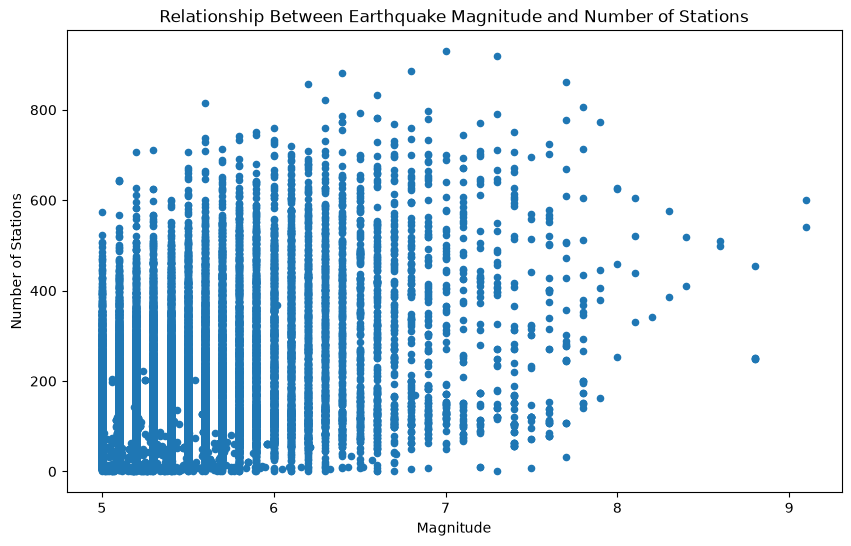

In [52]:
station_relation.plot(
    kind='scatter',
    x='mag',
    y='nst',
    title='Relationship Between Earthquake Magnitude and Number of Stations',
    xlabel='Magnitude',
    ylabel='Number of Stations',
    figsize=(10, 6)
);

**Finding:** The correlation between earthquake magnitude and the number of reporting stations (nst) is approximately 0.46, indicating a moderate positive linear relationship. This means that higher-magnitude earthquakes tend to be recorded using a larger number of stations.

### Objective 7 
What event types are recorded in the dataset, and how do their magnitude and depth differ?

In [53]:
earthquake_df['type'].value_counts()

type
earthquake           109282
nuclear explosion       424
volcanic eruption        54
explosion                10
landslide                 4
rock burst                1
mine collapse             1
Name: count, dtype: int64

In [54]:
#depth = -1.4 km means the recorded event location is 1.4 km 
#above the reference sea-level surface used for depth.
type_analysis = earthquake_df.groupby('type')[['mag', 'depth']].mean()

type_analysis

,mag,depth
type,,
earthquake,5.442960,61.576159
explosion,5.590000,0.000000
landslide,5.250000,0.000000
mine collapse,5.180000,-1.400000
nuclear explosion,5.548986,0.462288
rock burst,5.400000,1.000000
volcanic eruption,5.288889,0.247593


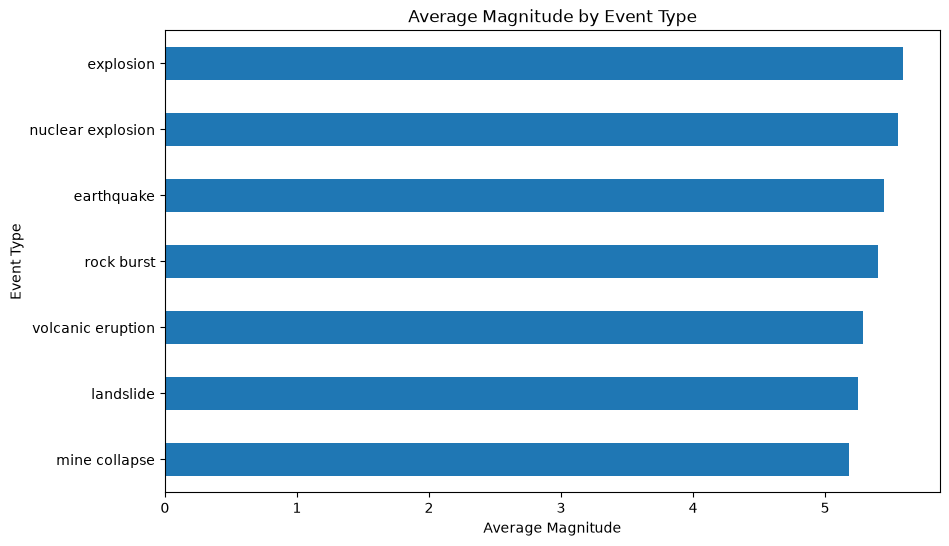

In [56]:
type_analysis['mag'].sort_values().plot(
    kind='barh',
    title='Average Magnitude by Event Type',
    xlabel='Average Magnitude',
    ylabel='Event Type',
    figsize=(10, 6)
);

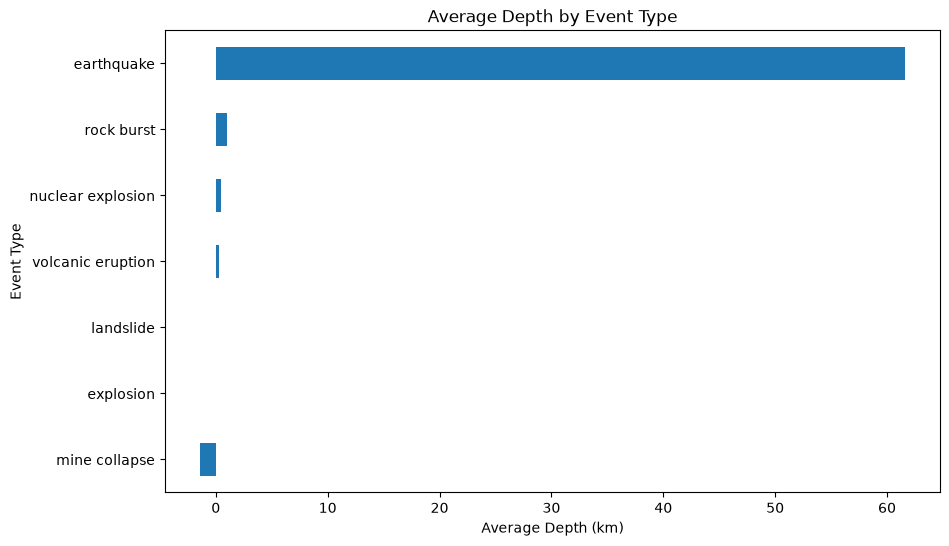

In [58]:
type_analysis['depth'].sort_values().plot(
    kind='barh',
    title='Average Depth by Event Type',
    xlabel='Average Depth (km)',
    ylabel='Event Type',
    figsize=(10, 6)
);

**Finding:** Seven different seismic event types were found in the dataset. Their average magnitudes were relatively similar, ranging from approximately 5.18 to 5.59. However, their average depths differed considerably. Earthquakes had an average depth of about 61.58 km, while most other event types were recorded close to the surface.

---

## Summary

- The South Sandwich Islands region had the highest recorded earthquake frequency with 2,509 events.
- The strongest earthquake in the dataset was the 1960 Great Chilean (Valdivia) Earthquake, with a magnitude of 9.5.
- Recorded earthquake frequency generally increased over time, while average magnitude decreased and became relatively stable at around 5.3–5.4 in recent decades.
- Earthquake depth and magnitude showed almost no linear relationship, with a correlation of approximately -0.01.
- Earthquake frequency was relatively similar across months, with March recording the highest number (9,833).
- Magnitude and number of reporting stations showed a moderate positive correlation of 0.46.
- Earthquakes were considerably deeper on average (61.58 km) than the other seismic event types in the dataset.

---

## Recommendations

- Areas with a history of frequent or high-magnitude earthquakes should receive greater attention when assessing earthquake preparedness and infrastructure needs.
- Historical earthquake patterns can support planning, but they should not be used alone to predict future earthquakes.
- Earthquake frequency alone should not determine risk; magnitude, depth, location, population exposure, and infrastructure conditions should also be considered.
- Future analysis could combine the earthquake data with population, infrastructure, and geological data to provide a more complete assessment of earthquake risk.
- Improvements in earthquake detection and reporting over time should be considered when interpreting the increase in recorded earthquake frequency.